In [33]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [34]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import cross_val_score
from sklearn.metrics import r2_score,mean_squared_error,mean_absolute_error

In [35]:
df=pd.read_csv("cross_validation_student_scores.csv")

In [36]:
df.head()

,Hours_Studied,Experience_Years,Attendance_Percent,Assignments_Completed,Exam_Score
0,4.4,1,73.6,5,91.5
1,9.6,6,64.5,4,100.0
2,7.6,3,97.0,8,100.0
3,6.4,0,95.1,9,100.0
4,2.4,6,70.3,5,95.7


In [37]:
df.isnull().sum()

Hours_Studied            0
Experience_Years         0
Attendance_Percent       0
Assignments_Completed    0
Exam_Score               0
dtype: int64

In [38]:
df.duplicated().sum()

np.int64(0)

In [39]:
# seperate X and y

In [40]:
X=df.drop('Exam_Score',axis=1)
y=df['Exam_Score']

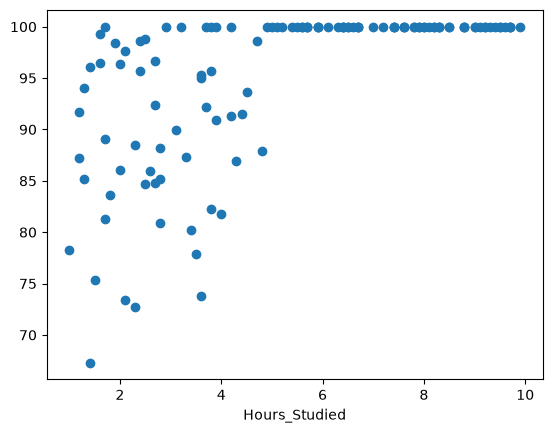

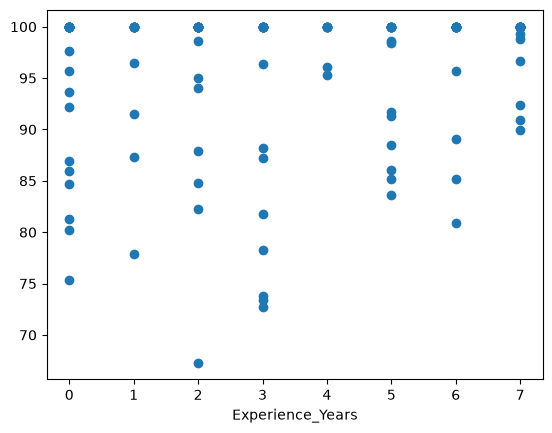

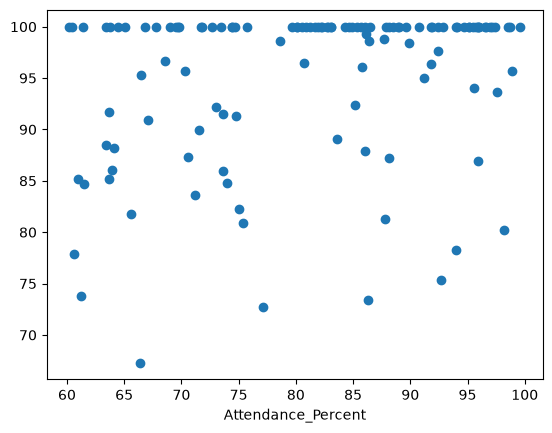

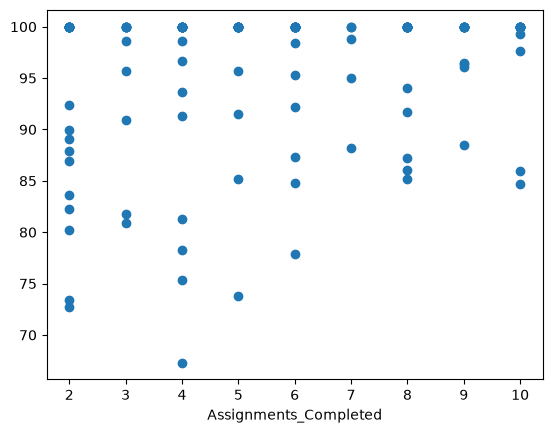

In [41]:
for i in X.columns:
    plt.figure()
    plt.scatter(df[i],df['Exam_Score'])
    plt.xlabel(i)

In [42]:
# train_test_split

In [43]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [44]:
lr=LinearRegression()

In [45]:
lr.fit(X_train,y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](4,)","[1.9 ,0.9 ,0.19,0.94]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](4,)","['Hours_Studied','Experience_Years','Attendance_Percent', 'Assignments_Completed']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,61.71
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,4
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(4)


In [46]:
# Training data prediction

In [47]:
ypred=lr.predict(X_train)

In [48]:
r2_score(y_train,ypred)

0.5816615266789802

In [49]:
# prediction on testing

In [50]:
y_pred=lr.predict(X_test)

In [51]:
r2_score(y_test,y_pred)

0.633479787983005

In [52]:
# method 2 for finding accuracy

In [53]:
# perform cross validation

In [54]:
model=LinearRegression()

In [55]:
scores=cross_val_score(
    model,
    X_train,
    y_train,
    cv=5,
    scoring="r2"
)

In [56]:
print(scores)

[0.58051302 0.47794513 0.59468893 0.56775924 0.51324815]


In [57]:
print(scores.mean())

0.5468308954795622
